ge: 7.9863e+09 Hz 

ef: 7.6643e+09 Hz

In [3]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

## ge遷移
初期値設定

In [6]:
header = "D:/K_sunada/result/CDY151/"
ge ="/2023-11-07/2023-11-07T185609_e020004c-cw_twotone"
ddge = datadict_from_hdf5(header + ge +"/data")

In [7]:
ddge

s11: (21, 81)
  ⌙ frequency (Hz): (21, 81)
  ⌙ power (dBm): (21,)

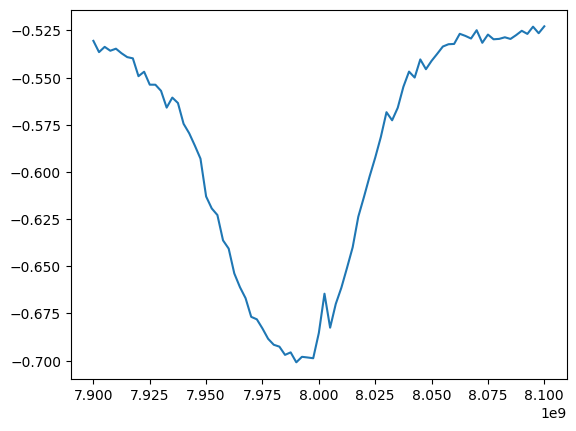

In [8]:
S11ge = ddge['s11']['values']
ge_phase = np.angle(S11ge)
freqge = ddge['frequency']['values']

y = ge_phase[0]
x = freqge[0]

plt.plot(x, y)
plt.show()

PCA

In [9]:
I = (S11ge.real)[0]
Q = (S11ge.imag)[0]
#c_data = np.concatenate([np.array([I]).T, np.array([Q]).T], axis = 1)

In [10]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [11]:
PCAge = PCA_transform(I, Q)

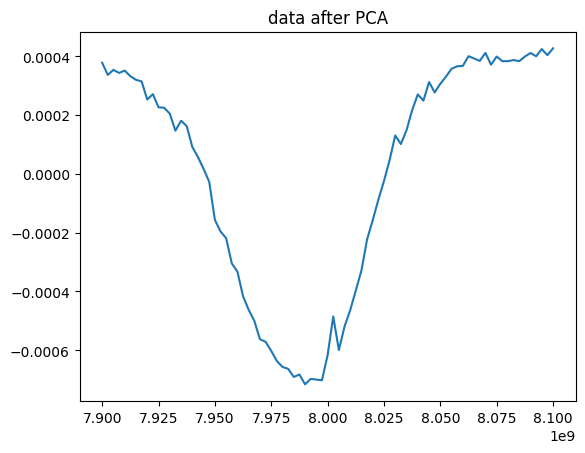

In [12]:
y = PCAge[0]
x = freqge[0]

plt.plot(x, -y)
plt.title("data after PCA")
plt.show()

In [13]:
par_ini = {
    'amp': 10e-4,
    'const':0,
    'center':7.98e9,
    'k':0.008e9
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

fitting

In [14]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [15]:
result = model.fit(data = -y, params = params, freq = x)

In [16]:
result

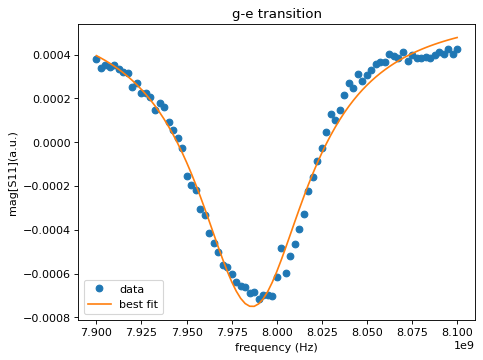

In [17]:
fig, ax = plt.subplots(dpi=80)

plt.title("g-e transition")


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)

plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

## ef
初期値

In [18]:
gf = "/2023-11-07/2023-11-07T185945_6133072d-cw_twotone"
ddgf = datadict_from_hdf5(header +gf +"/data")

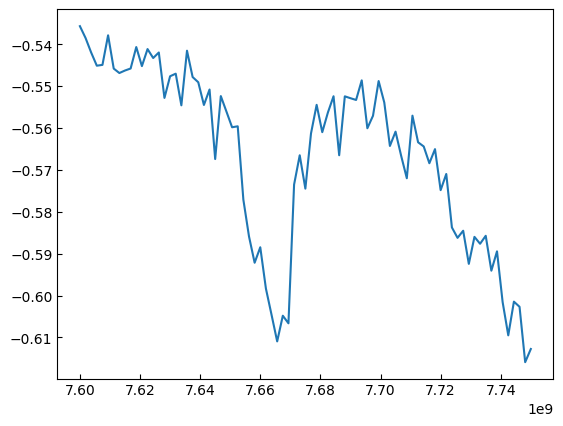

In [30]:
S11gf = ddgf['s11']['values']
maggf = np.angle(S11gf)
freqgf = ddgf['frequency']['values']

x = freqgf[3]
y = maggf[3]


plt.plot(x, y)
plt.show()

In [20]:
I = (S11gf.real)[3]
Q = (S11gf.imag)[3]
#c_data = np.concatenate([np.array([I]).T, np.array([Q]).T], axis = 1)

In [21]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [22]:
PCAgf = PCA_transform(I, Q)

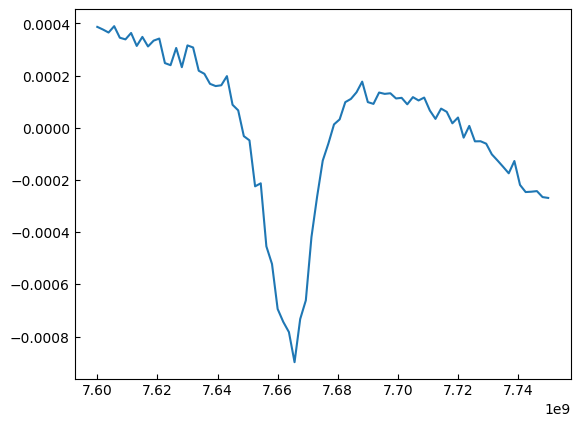

In [23]:
y = PCAgf[0]
x = freqgf[0]

plt.plot(x, -y)
plt.show()

In [24]:
par_ini = {
    'amp': 1.1e-3,
    'const':0,
    'center':7.67e9,
    'k':0.001e9
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [25]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [26]:
result1 = model.fit(data = -y, params = params, freq = x)

In [27]:
result1

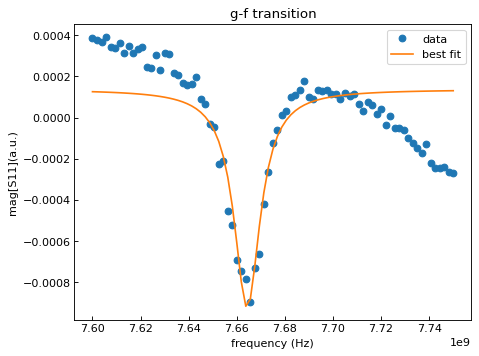

In [28]:
fig, ax = plt.subplots(dpi=80)
plt.title("g-f transition")


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)

plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")

plt.show()